In [1]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, isnull, lit, mean, stddev
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
import pandas as pd
import numpy as np

In [2]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("Rishika Vijayakumar") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Check Spark context
print("Spark Session Created Successfully!")
print(f"Spark Version: {spark.version}")
print(f"Application Name: {spark.sparkContext.appName}")

Spark Session Created Successfully!
Spark Version: 4.0.1
Application Name: Rishika Vijayakumar


In [4]:
# Load the dataset
file_path = "/content/customer_dataset_missing.csv"

df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# Display dataset schema
df.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Age: double (nullable = true)
 |-- Gender: string (nullable = true)
 |-- City: string (nullable = true)
 |-- AnnualIncome: double (nullable = true)
 |-- SpendingScore: double (nullable = true)
 |-- MembershipYears: double (nullable = true)
 |-- HasCreditCard: integer (nullable = true)
 |-- OnlinePurchases: integer (nullable = true)



In [6]:
# Show first 10 rows
df.show(10)

+----------+----+------+------------+------------+-------------+---------------+-------------+---------------+
|CustomerID| Age|Gender|        City|AnnualIncome|SpendingScore|MembershipYears|HasCreditCard|OnlinePurchases|
+----------+----+------+------------+------------+-------------+---------------+-------------+---------------+
|         1|56.0|  Male|        Ipoh|     89306.0|         51.0|            8.0|            0|              6|
|         2|69.0|Female|Kuala Lumpur|     39726.0|         35.0|           NULL|            0|             28|
|         3|46.0|Female|Kuala Lumpur|    132753.0|         82.0|            6.0|            0|             43|
|         4|NULL|  Male|       Johor|     29088.0|         53.0|            0.0|            1|             16|
|         5|NULL|  Male|      Penang|     54314.0|         19.0|            3.0|            0|              8|
|         6|25.0|Female|        Ipoh|    137814.0|         69.0|            9.0|            0|              5|
|

In [7]:
# Total number of rows
print("Total number of rows:", df.count())

Total number of rows: 5000


In [8]:
from pyspark.sql.functions import sum

# Count missing values in each column
missing_before = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_before.show()

+----------+---+------+----+------------+-------------+---------------+-------------+---------------+
|CustomerID|Age|Gender|City|AnnualIncome|SpendingScore|MembershipYears|HasCreditCard|OnlinePurchases|
+----------+---+------+----+------------+-------------+---------------+-------------+---------------+
|         0|500|     0| 500|         500|          500|            500|            0|              0|
+----------+---+------+----+------------+-------------+---------------+-------------+---------------+



In [9]:
# Separate numerical and categorical columns
numerical_cols = [field.name for field in df.schema.fields
                  if field.dataType.simpleString() in ['int', 'double']]

categorical_cols = [field.name for field in df.schema.fields
                     if field.dataType.simpleString() == 'string']

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['CustomerID', 'Age', 'AnnualIncome', 'SpendingScore', 'MembershipYears', 'HasCreditCard', 'OnlinePurchases']
Categorical Columns: ['Gender', 'City']


In [10]:
# Fill missing numerical values with mean
for col_name in numerical_cols:
    mean_value = df.select(mean(col(col_name))).collect()[0][0]
    df = df.fillna({col_name: mean_value})

In [11]:
# Fill missing categorical values with mode
for col_name in categorical_cols:
    mode_value = (
        df.groupBy(col_name)
        .count()
        .orderBy(col("count").desc())
        .first()[0]
    )
    df = df.fillna({col_name: mode_value})

In [13]:
# Check missing values after cleaning
missing_after = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_after.show()
df.show(10)

+----------+---+------+----+------------+-------------+---------------+-------------+---------------+
|CustomerID|Age|Gender|City|AnnualIncome|SpendingScore|MembershipYears|HasCreditCard|OnlinePurchases|
+----------+---+------+----+------------+-------------+---------------+-------------+---------------+
|         0|  0|     0|   0|           0|            0|              0|            0|              0|
+----------+---+------+----+------------+-------------+---------------+-------------+---------------+

+----------+------------------+------+------------+-----------------+-------------+-----------------+-------------+---------------+
|CustomerID|               Age|Gender|        City|     AnnualIncome|SpendingScore|  MembershipYears|HasCreditCard|OnlinePurchases|
+----------+------------------+------+------------+-----------------+-------------+-----------------+-------------+---------------+
|         1|              56.0|  Male|        Ipoh|          89306.0|         51.0|          

In [14]:
# Convert to Pandas DataFrame
pdf = df.toPandas()

print("Converted to Pandas DataFrame")

Converted to Pandas DataFrame


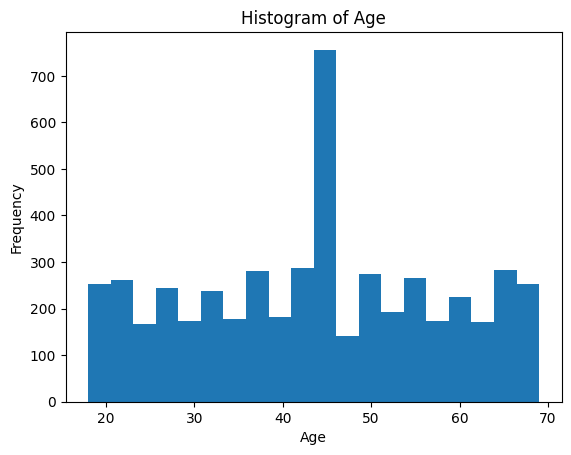

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(pdf['Age'], bins=20)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

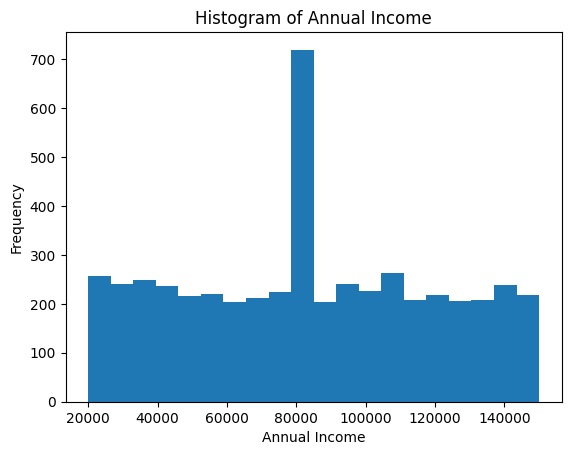

In [17]:
plt.figure()
plt.hist(pdf['AnnualIncome'], bins=20)
plt.title("Histogram of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

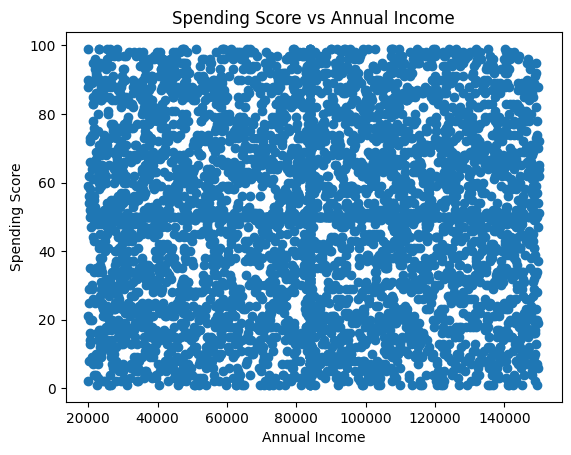

In [19]:
plt.figure()
plt.scatter(pdf['AnnualIncome'], pdf['SpendingScore'])
plt.title("Spending Score vs Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

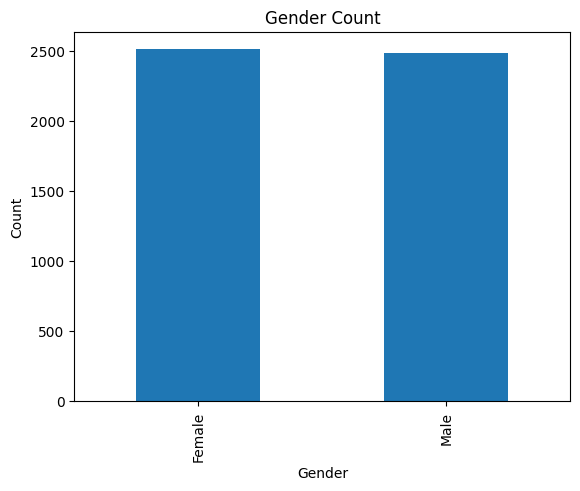

In [20]:
gender_counts = pdf['Gender'].value_counts()

plt.figure()
gender_counts.plot(kind='bar')
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()